In [6]:
import sys
import os

# Fix import path
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('.'))

print("✅ Path fixed successfully!")

✅ Path fixed successfully!


In [8]:
from src.data_preprocessing import generate_synthetic_data, preprocess_data
from src.clustering import run_kmeans
from src.pca_analysis import run_pca, plot_scree
from src.chatbot import chatbot_response

import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Generate data
df = generate_synthetic_data(1200)
print("Data generated successfully!")
df

Data generated successfully!


,user_id,monthly_income,transaction_frequency,avg_loan_size,savings_rate,digital_literacy_score,chatbot_sessions,response_time_sec,engagement_score,region,business_type
0,1,12056,20,46426,0.021982,64.797451,4,21.371175,0.349179,Nairobi,Agriculture
1,2,7254,9,60890,0.011993,48.399005,9,43.679560,0.617102,Mombasa,Services
2,3,13604,13,11597,0.030540,60.504598,9,76.370679,0.475646,Nairobi,Services
3,4,27403,10,12260,0.023443,53.548020,3,36.617324,0.521792,Nairobi,Manufacturing
4,5,6718,15,19965,0.004952,70.751825,7,20.254900,0.732764,Kisumu,Agriculture
...,...,...,...,...,...,...,...,...,...,...,...
1195,1196,11526,7,21875,0.036989,59.761072,5,42.680575,0.695806,Mombasa,Services
1196,1197,7976,14,6755,0.012316,89.247825,9,56.889330,0.622735,Nairobi,Agriculture
1197,1198,12606,10,10056,0.016619,55.110138,11,20.425465,0.421064,Nairobi,Manufacturing
1198,1199,9692,14,35229,0.031329,60.225485,9,38.500428,0.509295,Nairobi,Manufacturing


In [11]:
# Preprocess
X_scaled, features, scaler = preprocess_data(df)

In [14]:
# Run K-Means
labels, kmeans_model = run_kmeans(X_scaled, 4)
df['cluster'] = labels

print("✅ Clustering completed!")
print("\nCluster Distribution:")
print(df['cluster'].value_counts())

print("\nCluster Profiles (Average values):")
print(df.groupby('cluster')[features].mean().round(2))

✅ Clustering completed!

Cluster Distribution:
cluster
1    488
0    488
2    112
3    112
Name: count, dtype: int64

Cluster Profiles (Average values):
         monthly_income  transaction_frequency  avg_loan_size  savings_rate  \
cluster                                                                       
0               8468.80                  11.64       21770.95          0.01   
1               9204.44                  12.31       21219.89          0.01   
2               9784.27                  11.87       70838.12          0.02   
3              36199.03                  12.35       26311.73          0.07   

         digital_literacy_score  chatbot_sessions  response_time_sec  \
cluster                                                                
0                         73.33              8.18              44.58   
1                         55.86              8.17              46.05   
2                         64.48              8.43              44.14   
3           

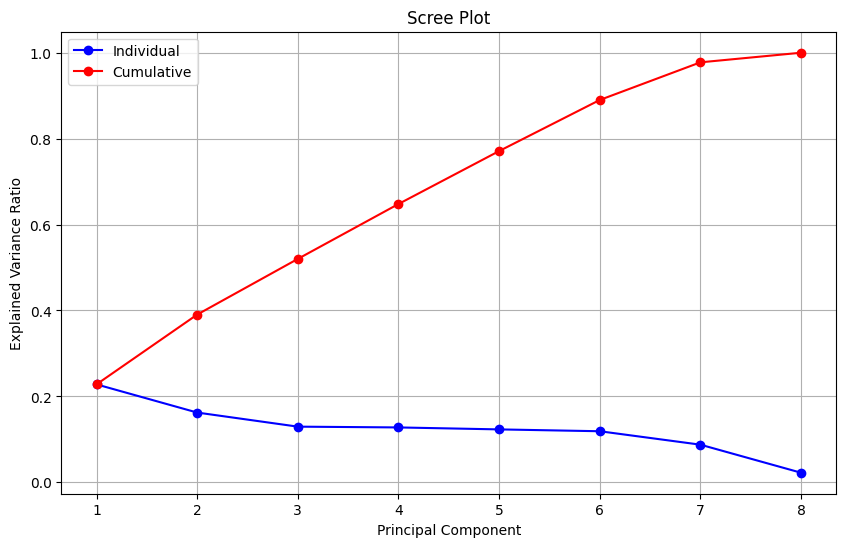

array([0.22800622, 0.39043249, 0.52004694, 0.64783578, 0.77105509,
       0.88998273, 0.9776312 , 1.        ])

In [15]:
# PCA
pca, X_pca = run_pca(X_scaled)
plot_scree(pca)

In [16]:
# Chatbot Demo
print("\n=== Chatbot Demo ===\n")
test_query = "How can I better manage my cash flow?"
response = chatbot_response(test_query, cluster_id=1, 
                          user_data=df.iloc[0].to_dict())
print(response)


=== Chatbot Demo ===

Hujambo! * waves * As MESH Money Coach, I'm here to help you manage your cash flow effectively. Here are some practical tips for a rural agricultural MSME like yours:

1. Keep track of income and expenses: Use a simple ledger or an app like M-Pesa's 'My Account' feature to record all your transactions. This will help you identify areas where you can cut costs and optimize your cash flow.
2. Create a budget: Allocate your income into different categories such as savings, expenses, and investments. Be realistic and flexible, so you can adjust your budget as needed.
3. Prioritize payments: Make sure to prioritize essential expenses like rent/mortgage, utilities, and salaries before allocating funds for discretionary spending.
4. Build a cash reserve: Aim to save 3-6 months' worth of living expenses as an emergency fund in case of unexpected events or cash flow disruptions.
5. Consider invoice financing: If you have a steady stream of invoices, consider using invoice

In [18]:
response = chatbot_response(
    user_query="How can I save more money?",
    cluster_id=1,
    user_data={"monthly_income": 28000, "digital_literacy_score": 48, "engagement_score": 0.42}
)

In [19]:
print(response)

Heya there! *smiling* Nice to meet you! 😊

Saving money can be a bit tricky, but with a few simple tips, you can reach your savings goals in no time! 💸 Here's what I suggest:

1. Create a budget: Start by tracking your income and expenses. Write down everything you spend money on for a month. This will help you identify areas where you can cut back.
2. Set financial goals: What do you want to save for? Is it a big purchase, like a new tractor or something more long-term, like saving for your children's education? Write down your goals and keep them somewhere visible.
3. Automate your savings: Set up automatic transfers from your checking account to your savings account. This way, you won't even miss the money! 💻
4. Cut back on unnecessary expenses: Take a closer look at your budget and see where you can cut back on non-essential spending. Could be things like eating out or buying expensive snacks? Find ways to save money without feeling too much of a pinch. 🍔🥤
5. Save your change: At t